<a href="https://colab.research.google.com/github/minahss/covid-cxr-ai-medicine/blob/main/01_mobilenetv2_twostage_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# COVID-19 Radiography Project — MobileNetV2 Final Two-Stage Version

Main idea:
- Stage 1: train only the new classifier head while MobileNetV2 is frozen.
- Stage 2: fine-tune the last MobileNetV2 layers with a small learning rate.
- Final evaluation is done once on the untouched test set.

Leakage prevention:
- Exact duplicate files are removed using SHA-256 before splitting.
- Train/validation/test split is stratified.
- Class weights are computed only from the training set.
- Data augmentation is applied only to training images.
- The test set is not used for model selection.


In [ ]:
!pip -q install kagglehub

import os
import random
import hashlib
from pathlib import Path
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_fscore_support,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve
)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf

RANDOM_STATE = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

STAGE1_EPOCHS = 10
STAGE2_EPOCHS = 30

STAGE1_PATIENCE = 3
STAGE2_PATIENCE = 5

STAGE1_LR = 1e-3
STAGE2_LR = 1e-5

N_FINE_TUNE_LAYERS = 30

STAGE1_MODEL_PATH = "mobilenetv2_stage1_best_validation.keras"
FINAL_MODEL_PATH = "mobilenetv2_twostage_best_validation.keras"

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print("TensorFlow version:", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices("GPU")) > 0)

TensorFlow version: 2.20.0
GPU available: True


## 1. Load dataset and remove exact duplicates

In [ ]:
import kagglehub

dataset_path = Path(kagglehub.dataset_download("tawsifurrahman/covid19-radiography-database"))

possible_root = dataset_path / "COVID-19_Radiography_Dataset"
data_root = possible_root if possible_root.exists() else dataset_path

class_names = ["COVID", "Lung_Opacity", "Normal", "Viral Pneumonia"]

records = []

for class_name in class_names:
    class_dir = data_root / class_name
    image_dir = class_dir / "images"
    if not image_dir.exists():
        image_dir = class_dir

    image_paths = []
    for ext in ["*.png", "*.jpg", "*.jpeg"]:
        image_paths.extend(image_dir.glob(ext))

    for path in image_paths:
        records.append({"path": str(path), "label": class_name})

df = pd.DataFrame(records)

# SHA-256 detects exact duplicate files.
# Exact duplicates are removed before splitting to reduce leakage risk.
def sha256_file(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(8192), b""):
            h.update(chunk)
    return h.hexdigest()

df["sha256"] = df["path"].apply(sha256_file)
n_duplicates = df["sha256"].duplicated().sum()

df_clean = df.drop_duplicates(subset="sha256", keep="first").reset_index(drop=True)

print("Original images:", len(df))
print("Exact duplicates removed:", n_duplicates)
print("Images after duplicate removal:", len(df_clean))

display(df_clean["label"].value_counts().loc[class_names])

Using Colab cache for faster access to the 'covid19-radiography-database' dataset.
Original images: 21165
Exact duplicates removed: 54
Images after duplicate removal: 21111


,count
label,
COVID,3570
Lung_Opacity,6012
Normal,10191
Viral Pneumonia,1338


## 2. Basic image checks

In [ ]:
# Basic check of image sizes and modes.
# This confirms whether images are consistent before preprocessing.

sizes = []
modes = []

for path in df_clean["path"].values:
    with Image.open(path) as img:
        sizes.append(img.size)
        modes.append(img.mode)

size_counts = pd.Series(sizes).value_counts()
mode_counts = pd.Series(modes).value_counts()

print("Image sizes:")
display(size_counts.head())

print("Image modes:")
display(mode_counts)

Image sizes:


,count
"(299, 299)",21111


Image modes:


,count
L,20971
RGB,140


## 3. Stratified train/validation/test split

In [ ]:
# The split is stratified by class.
# The test set is kept untouched until final evaluation.

train_df, temp_df = train_test_split(
    df_clean,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=df_clean["label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=temp_df["label"]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

split_counts = pd.DataFrame({
    "train": train_df["label"].value_counts(),
    "validation": val_df["label"].value_counts(),
    "test": test_df["label"].value_counts()
}).loc[class_names]

display(split_counts)

# Save split files so the final project can reproduce the exact split.
train_df.to_csv("split_train.csv", index=False)
val_df.to_csv("split_val.csv", index=False)
test_df.to_csv("split_test.csv", index=False)

print("Saved split_train.csv, split_val.csv, split_test.csv")

Train: (14777, 3)
Validation: (3167, 3)
Test: (3167, 3)


,train,validation,test
label,,,
COVID,2499,536,535
Lung_Opacity,4208,902,902
Normal,7133,1529,1529
Viral Pneumonia,937,200,201


Saved split_train.csv, split_val.csv, split_test.csv


## 4. Label encoding and TensorFlow datasets

In [ ]:
label_to_id = {name: i for i, name in enumerate(class_names)}
id_to_label = {i: name for name, i in label_to_id.items()}

for split_df in [train_df, val_df, test_df]:
    split_df["label_id"] = split_df["label"].map(label_to_id)

print(label_to_id)

{'COVID': 0, 'Lung_Opacity': 1, 'Normal': 2, 'Viral Pneumonia': 3}


In [ ]:
def load_image(path, label):
    image = tf.io.read_file(path)

    # All images are decoded as 3-channel RGB to match pretrained CNN input.
    image = tf.image.decode_image(image, channels=3, expand_animations=False)

    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

def make_dataset(split_df, shuffle=False):
    paths = split_df["path"].values
    labels = split_df["label_id"].values.astype(np.int32)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(buffer_size=1000, seed=RANDOM_STATE)

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, shuffle=True)
val_ds = make_dataset(val_df, shuffle=False)
test_ds = make_dataset(test_df, shuffle=False)

images, labels = next(iter(train_ds))
print("Batch shape:", images.shape)
print("Pixel range:", float(tf.reduce_min(images)), "to", float(tf.reduce_max(images)))

Batch shape: (32, 224, 224, 3)
Pixel range: 0.0 to 1.0


## 5. Majority baseline

In [ ]:
# Baseline: always predict the most frequent training class.
# This gives a reference floor for the CNN results.

test_true_for_baseline = test_df["label_id"].values
majority_class = train_df["label_id"].mode()[0]
baseline_pred = np.full_like(test_true_for_baseline, fill_value=majority_class)

baseline_metrics = pd.DataFrame([{
    "Model": "Majority baseline",
    "Majority class": id_to_label[majority_class],
    "Accuracy": accuracy_score(test_true_for_baseline, baseline_pred),
    "Balanced accuracy": balanced_accuracy_score(test_true_for_baseline, baseline_pred)
}])

display(baseline_metrics.round(4))

print(classification_report(
    test_true_for_baseline,
    baseline_pred,
    target_names=class_names,
    digits=4,
    zero_division=0
))

,Model,Majority class,Accuracy,Balanced accuracy
0,Majority baseline,Normal,0.4828,0.25


                 precision    recall  f1-score   support

          COVID     0.0000    0.0000    0.0000       535
   Lung_Opacity     0.0000    0.0000    0.0000       902
         Normal     0.4828    1.0000    0.6512      1529
Viral Pneumonia     0.0000    0.0000    0.0000       201

       accuracy                         0.4828      3167
      macro avg     0.1207    0.2500    0.1628      3167
   weighted avg     0.2331    0.4828    0.3144      3167



## 6. Class weights

In [ ]:
# Class weights are computed only from the training set.
# This helps minority classes without using validation/test information.

class_weights_values = compute_class_weight(
    class_weight="balanced",
    classes=np.array(range(len(class_names))),
    y=train_df["label_id"].values
)

class_weights = {i: float(weight) for i, weight in enumerate(class_weights_values)}

for class_id, weight in class_weights.items():
    print(id_to_label[class_id], ":", round(weight, 3))

COVID : 1.478
Lung_Opacity : 0.878
Normal : 0.518
Viral Pneumonia : 3.943


## 7. Build MobileNetV2 model

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.03),
    tf.keras.layers.RandomZoom(0.08),
], name="data_augmentation")

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    include_top=False,
    weights="imagenet",
    name="mobilenetv2_base"
)

# Stage 1 starts with frozen pretrained base.
base_model.trainable = False

inputs = tf.keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3), name="input_image")
x = data_augmentation(inputs)
x = tf.keras.layers.Rescaling(2.0, offset=-1.0, name="mobilenet_rescaling")(x)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D(name="global_average_pooling")(x)
x = tf.keras.layers.Dropout(0.3, name="dropout")(x)
outputs = tf.keras.layers.Dense(len(class_names), activation="softmax", name="classifier")(x)

model = tf.keras.Model(inputs, outputs, name="MobileNetV2_TwoStage_CXR")

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2_TwoStage_CXR"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenet_rescaling (Rescaling) │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_base (Functional)   │ (None, 7, 7, 1280)     │     2,257,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,263,108 (8.63 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 8. Stage 1 — Frozen MobileNetV2 base

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=STAGE1_LR),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

stage1_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=STAGE1_PATIENCE,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        STAGE1_MODEL_PATH,
        monitor="val_loss",
        save_best_only=True
    )
]

history_stage1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=STAGE1_EPOCHS,
    class_weight=class_weights,
    callbacks=stage1_callbacks
)

print("Stage 1 complete.")

Epoch 1/10
462/462 ━━━━━━━━━━━━━━━━━━━━ 60s 106ms/step - accuracy: 0.7039 - loss: 0.6423 - val_accuracy: 0.7840 - val_loss: 0.5623
Epoch 2/10
462/462 ━━━━━━━━━━━━━━━━━━━━ 45s 93ms/step - accuracy: 0.7886 - loss: 0.4603 - val_accuracy: 0.7812 - val_loss: 0.5469
Epoch 3/10
462/462 ━━━━━━━━━━━━━━━━━━━━ 82s 91ms/step - accuracy: 0.8029 - loss: 0.4234 - val_accuracy: 0.7967 - val_loss: 0.5112
Epoch 4/10
462/462 ━━━━━━━━━━━━━━━━━━━━ 44s 92ms/step - accuracy: 0.8128 - loss: 0.4130 - val_accuracy: 0.7174 - val_loss: 0.6932
Epoch 5/10
462/462 ━━━━━━━━━━━━━━━━━━━━ 46s 93ms/step - accuracy: 0.8125 - loss: 0.4079 - val_accuracy: 0.7973 - val_loss: 0.5203
Epoch 6/10
462/462 ━━━━━━━━━━━━━━━━━━━━ 49s 103ms/step - accuracy: 0.8155 - loss: 0.3951 - val_accuracy: 0.8118 - val_loss: 0.4715
Epoch 7/10
462/462 ━━━━━━━━━━━━━━━━━━━━ 43s 89ms/step - accuracy: 0.8228 - loss: 0.3868 - val_accuracy: 0.8093 - val_loss: 0.4942
Epoch 8/10
462/462 ━━━━━━━━━━━━━━━━━━━━ 44s 92ms/step - accuracy: 0.8176 - loss: 0.3931 

## 9. Stage 2 — Fine-tune last MobileNetV2 layers

In [ ]:
# Fine-tuning: unfreeze only the last N layers.
# BatchNormalization layers stay frozen for stability during fine-tuning.

base_model.trainable = True

for layer in base_model.layers[:-N_FINE_TUNE_LAYERS]:
    layer.trainable = False

for layer in base_model.layers[-N_FINE_TUNE_LAYERS:]:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False
    else:
        layer.trainable = True

print("Total layers in MobileNetV2 base:", len(base_model.layers))
print("Fine-tuning last layers:", N_FINE_TUNE_LAYERS)
print("Trainable layers in base after setup:", sum(layer.trainable for layer in base_model.layers))

# Important: use base_model(x, training=False) in the model graph.
# This keeps BatchNorm behavior stable while still allowing trainable convolutional layers to update.

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=STAGE2_LR),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

stage2_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=STAGE2_PATIENCE,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        FINAL_MODEL_PATH,
        monitor="val_loss",
        save_best_only=True
    )
]

history_stage2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=STAGE2_EPOCHS,
    class_weight=class_weights,
    callbacks=stage2_callbacks
)

best_model = tf.keras.models.load_model(FINAL_MODEL_PATH)
print("Best fine-tuned validation model loaded.")

Total layers in MobileNetV2 base: 154
Fine-tuning last layers: 30
Trainable layers in base after setup: 19
Epoch 1/30
462/462 ━━━━━━━━━━━━━━━━━━━━ 54s 100ms/step - accuracy: 0.8339 - loss: 0.3573 - val_accuracy: 0.8462 - val_loss: 0.4023
Epoch 2/30
462/462 ━━━━━━━━━━━━━━━━━━━━ 79s 95ms/step - accuracy: 0.8530 - loss: 0.3210 - val_accuracy: 0.8658 - val_loss: 0.3632
Epoch 3/30
462/462 ━━━━━━━━━━━━━━━━━━━━ 48s 99ms/step - accuracy: 0.8686 - loss: 0.2811 - val_accuracy: 0.8049 - val_loss: 0.4973
Epoch 4/30
462/462 ━━━━━━━━━━━━━━━━━━━━ 47s 98ms/step - accuracy: 0.8737 - loss: 0.2646 - val_accuracy: 0.8683 - val_loss: 0.3468
Epoch 5/30
462/462 ━━━━━━━━━━━━━━━━━━━━ 47s 99ms/step - accuracy: 0.8862 - loss: 0.2486 - val_accuracy: 0.8674 - val_loss: 0.3424
Epoch 6/30
462/462 ━━━━━━━━━━━━━━━━━━━━ 50s 104ms/step - accuracy: 0.8922 - loss: 0.2277 - val_accuracy: 0.8601 - val_loss: 0.3672
Epoch 7/30
462/462 ━━━━━━━━━━━━━━━━━━━━ 45s 93ms/step - accuracy: 0.8916 - loss: 0.2211 - val_accuracy: 0.8762 

## 10. Training curves

,accuracy,loss,val_accuracy,val_loss,stage,epoch_in_stage,global_epoch
0,0.703864,0.642330,0.784023,0.562261,stage1_frozen,1,1
1,0.788590,0.460316,0.781181,0.546887,stage1_frozen,2,2
2,0.802937,0.423378,0.796653,0.511250,stage1_frozen,3,3
3,0.812817,0.412961,0.717398,0.693165,stage1_frozen,4,4
4,0.812479,0.407913,0.797284,0.520300,stage1_frozen,5,5
5,0.815456,0.395139,0.811809,0.471544,stage1_frozen,6,6
6,0.822765,0.386783,0.809283,0.494250,stage1_frozen,7,7
7,0.817622,0.393093,0.761288,0.601209,stage1_frozen,8,8
8,0.821006,0.391148,0.787180,0.531671,stage1_frozen,9,9
9,0.833863,0.357283,0.846227,0.402331,stage2_finetune,1,10


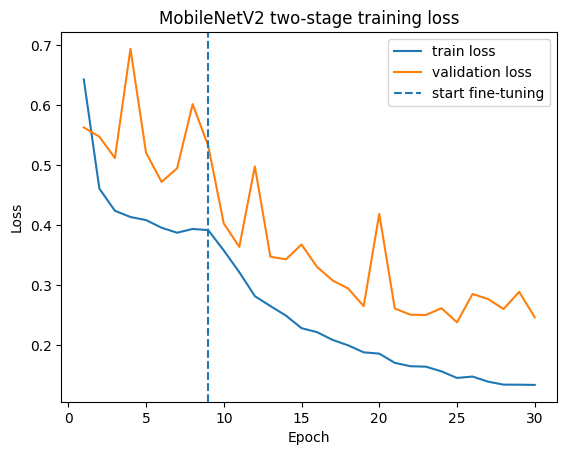

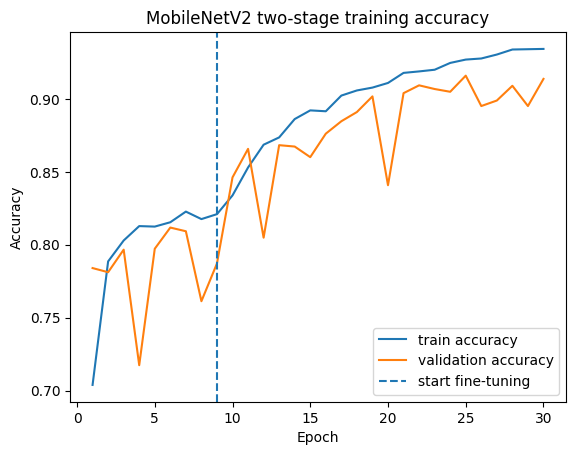

In [ ]:
stage1_df = pd.DataFrame(history_stage1.history)
stage1_df["stage"] = "stage1_frozen"
stage1_df["epoch_in_stage"] = np.arange(1, len(stage1_df) + 1)

stage2_df = pd.DataFrame(history_stage2.history)
stage2_df["stage"] = "stage2_finetune"
stage2_df["epoch_in_stage"] = np.arange(1, len(stage2_df) + 1)

history_df = pd.concat([stage1_df, stage2_df], ignore_index=True)
history_df["global_epoch"] = np.arange(1, len(history_df) + 1)

display(history_df)

plt.figure()
plt.plot(history_df["global_epoch"], history_df["loss"], label="train loss")
plt.plot(history_df["global_epoch"], history_df["val_loss"], label="validation loss")
plt.axvline(len(stage1_df), linestyle="--", label="start fine-tuning")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MobileNetV2 two-stage training loss")
plt.legend()
plt.show()

plt.figure()
plt.plot(history_df["global_epoch"], history_df["accuracy"], label="train accuracy")
plt.plot(history_df["global_epoch"], history_df["val_accuracy"], label="validation accuracy")
plt.axvline(len(stage1_df), linestyle="--", label="start fine-tuning")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MobileNetV2 two-stage training accuracy")
plt.legend()
plt.show()

## 11. Final test evaluation

In [ ]:
test_probs = best_model.predict(test_ds)
test_pred = np.argmax(test_probs, axis=1)
test_true = test_df["label_id"].values

test_accuracy = accuracy_score(test_true, test_pred)
test_balanced_accuracy = balanced_accuracy_score(test_true, test_pred)

precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    test_true,
    test_pred,
    average="macro",
    zero_division=0
)

precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
    test_true,
    test_pred,
    average="weighted",
    zero_division=0
)

mobilenet_metrics = pd.DataFrame([{
    "Model": "MobileNetV2 two-stage",
    "Accuracy": test_accuracy,
    "Balanced accuracy": test_balanced_accuracy,
    "Macro precision": precision_macro,
    "Macro recall": recall_macro,
    "Macro F1": f1_macro,
    "Weighted precision": precision_weighted,
    "Weighted recall": recall_weighted,
    "Weighted F1": f1_weighted
}])

display(mobilenet_metrics.round(4))

print(classification_report(
    test_true,
    test_pred,
    target_names=class_names,
    digits=4,
    zero_division=0
))

99/99 ━━━━━━━━━━━━━━━━━━━━ 10s 93ms/step


,Model,Accuracy,Balanced accuracy,Macro precision,Macro recall,Macro F1,Weighted precision,Weighted recall,Weighted F1
0,MobileNetV2 two-stage,0.917,0.9253,0.9209,0.9253,0.9229,0.9168,0.917,0.9167


                 precision    recall  f1-score   support

          COVID     0.9259    0.9346    0.9302       535
   Lung_Opacity     0.9084    0.8681    0.8878       902
         Normal     0.9165    0.9333    0.9248      1529
Viral Pneumonia     0.9327    0.9652    0.9487       201

       accuracy                         0.9170      3167
      macro avg     0.9209    0.9253    0.9229      3167
   weighted avg     0.9168    0.9170    0.9167      3167



## 12. Confusion matrix

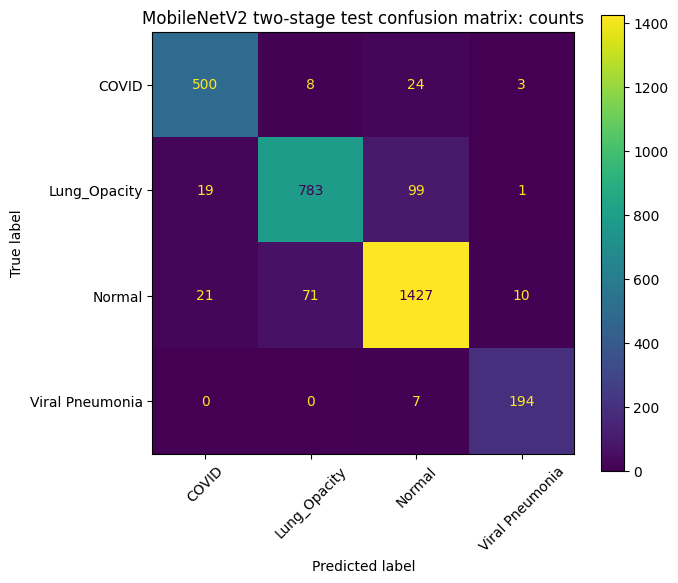

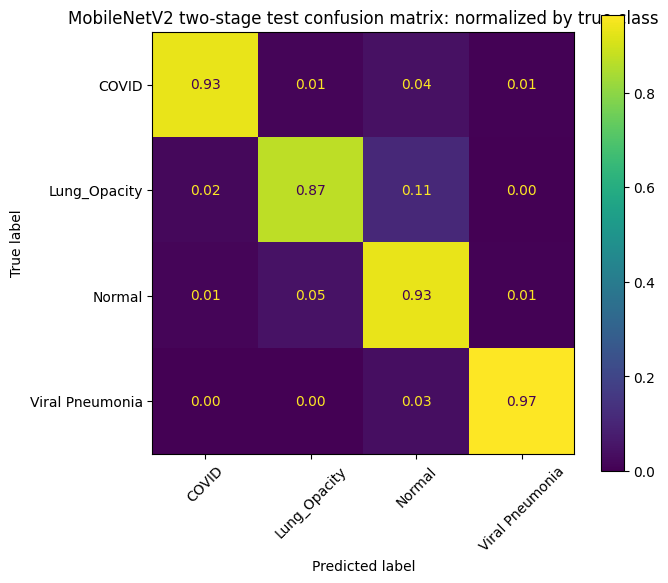

In [ ]:
cm = confusion_matrix(test_true, test_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, xticks_rotation=45)
plt.title("MobileNetV2 two-stage test confusion matrix: counts")
plt.tight_layout()
plt.show()

cm_norm = confusion_matrix(test_true, test_pred, normalize="true")

disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(7, 6))
disp_norm.plot(ax=ax, xticks_rotation=45, values_format=".2f")
plt.title("MobileNetV2 two-stage test confusion matrix: normalized by true class")
plt.tight_layout()
plt.show()

## 13. Sensitivity and specificity

In [ ]:
sensitivity_specificity_rows = []

for class_id, class_name in enumerate(class_names):
    y_true_binary = (test_true == class_id).astype(int)
    y_pred_binary = (test_pred == class_id).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true_binary, y_pred_binary).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

    sensitivity_specificity_rows.append({
        "Class": class_name,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
        "Sensitivity": sensitivity,
        "Specificity": specificity
    })

sensitivity_specificity_df = pd.DataFrame(sensitivity_specificity_rows)
display(sensitivity_specificity_df.round(4))

,Class,TP,FP,FN,TN,Sensitivity,Specificity
0,COVID,500,40,35,2592,0.9346,0.9848
1,Lung_Opacity,783,79,119,2186,0.8681,0.9651
2,Normal,1427,130,102,1508,0.9333,0.9206
3,Viral Pneumonia,194,14,7,2952,0.9652,0.9953


## 14. AUROC and AUPRC

In [ ]:
y_true_bin = label_binarize(test_true, classes=list(range(len(class_names))))

auroc_rows = []
auprc_rows = []

for class_id, class_name in enumerate(class_names):
    auroc = roc_auc_score(y_true_bin[:, class_id], test_probs[:, class_id])
    auprc = average_precision_score(y_true_bin[:, class_id], test_probs[:, class_id])

    auroc_rows.append({"Class": class_name, "AUROC": auroc})
    auprc_rows.append({"Class": class_name, "AUPRC": auprc})

auroc_macro = roc_auc_score(y_true_bin, test_probs, average="macro", multi_class="ovr")
auroc_weighted = roc_auc_score(y_true_bin, test_probs, average="weighted", multi_class="ovr")
auroc_micro = roc_auc_score(y_true_bin, test_probs, average="micro", multi_class="ovr")

auprc_macro = average_precision_score(y_true_bin, test_probs, average="macro")
auprc_weighted = average_precision_score(y_true_bin, test_probs, average="weighted")
auprc_micro = average_precision_score(y_true_bin, test_probs, average="micro")

auroc_df = pd.DataFrame(auroc_rows)
auprc_df = pd.DataFrame(auprc_rows)

display(auroc_df.round(4))
display(auprc_df.round(4))

summary_auc = pd.DataFrame([{
    "Macro AUROC": auroc_macro,
    "Weighted AUROC": auroc_weighted,
    "Micro AUROC": auroc_micro,
    "Macro AUPRC": auprc_macro,
    "Weighted AUPRC": auprc_weighted,
    "Micro AUPRC": auprc_micro
}])

display(summary_auc.round(4))

,Class,AUROC
0,COVID,0.9923
1,Lung_Opacity,0.9780
2,Normal,0.9769
3,Viral Pneumonia,0.9993


,Class,AUPRC
0,COVID,0.9777
1,Lung_Opacity,0.9558
2,Normal,0.9705
3,Viral Pneumonia,0.9914


,Macro AUROC,Weighted AUROC,Micro AUROC,Macro AUPRC,Weighted AUPRC,Micro AUPRC
0,0.9866,0.9812,0.9894,0.9739,0.9689,0.9706


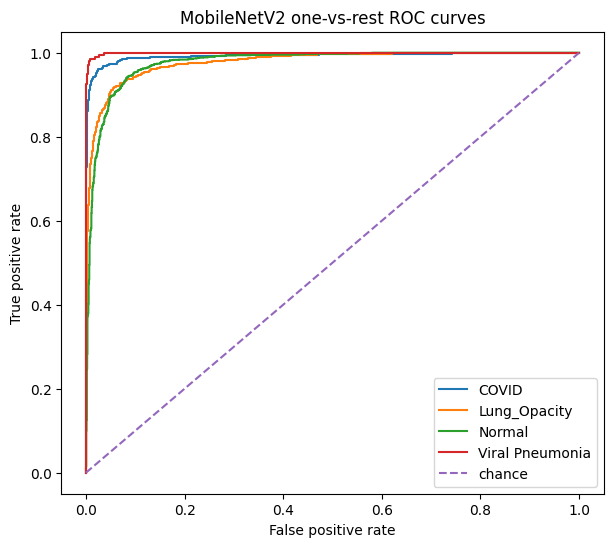

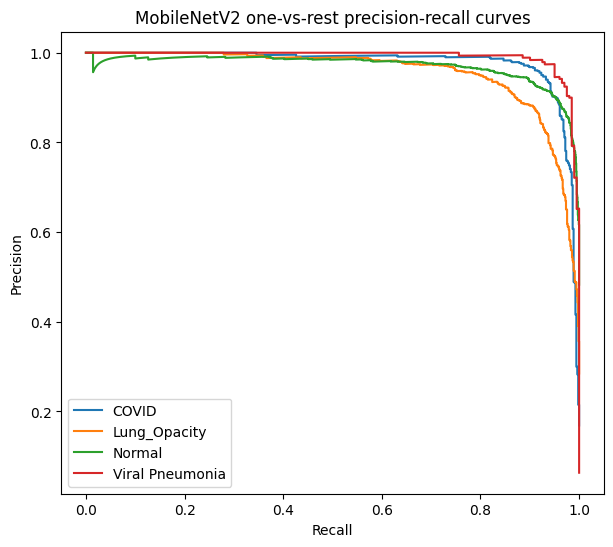

In [ ]:
plt.figure(figsize=(7, 6))

for class_id, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_true_bin[:, class_id], test_probs[:, class_id])
    plt.plot(fpr, tpr, label=f"{class_name}")

plt.plot([0, 1], [0, 1], linestyle="--", label="chance")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("MobileNetV2 one-vs-rest ROC curves")
plt.legend()
plt.show()

plt.figure(figsize=(7, 6))

for class_id, class_name in enumerate(class_names):
    precision, recall, _ = precision_recall_curve(y_true_bin[:, class_id], test_probs[:, class_id])
    plt.plot(recall, precision, label=f"{class_name}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("MobileNetV2 one-vs-rest precision-recall curves")
plt.legend()
plt.show()

## 15. High-confidence errors

In [ ]:
test_results = test_df[["path", "label", "label_id"]].copy()
test_results["pred_id"] = test_pred
test_results["pred_label"] = [id_to_label[i] for i in test_pred]
test_results["correct"] = test_results["label_id"] == test_results["pred_id"]
test_results["confidence"] = np.max(test_probs, axis=1)

errors = test_results[test_results["correct"] == False].sort_values("confidence", ascending=False)

print("Number of test errors:", len(errors))
display(errors[["label", "pred_label", "confidence", "path"]].head(15))

Number of test errors: 263


,label,pred_label,confidence,path
2294,COVID,Normal,0.999888,/kaggle/input/covid19-radiography-database/COV...
2542,Lung_Opacity,COVID,0.998964,/kaggle/input/covid19-radiography-database/COV...
2527,Normal,Viral Pneumonia,0.998177,/kaggle/input/covid19-radiography-database/COV...
1901,COVID,Normal,0.998099,/kaggle/input/covid19-radiography-database/COV...
2104,Lung_Opacity,Normal,0.997495,/kaggle/input/covid19-radiography-database/COV...
1557,Normal,COVID,0.997401,/kaggle/input/covid19-radiography-database/COV...
1245,Normal,Lung_Opacity,0.997038,/kaggle/input/covid19-radiography-database/COV...
2149,Normal,Lung_Opacity,0.995476,/kaggle/input/covid19-radiography-database/COV...
3036,Lung_Opacity,Normal,0.994078,/kaggle/input/covid19-radiography-database/COV...
596,Normal,Lung_Opacity,0.993752,/kaggle/input/covid19-radiography-database/COV...


## 16. Grad-CAM helper functions

In [ ]:
def preprocess_single_image(path):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    return image

def make_gradcam_heatmap(model, image_tensor, class_index=None, last_conv_layer_name="Conv_1"):
    # This explicit path avoids nested-model graph issues in Keras.
    base_model = model.get_layer("mobilenetv2_base")
    rescaling_layer = model.get_layer("mobilenet_rescaling")
    gap_layer = model.get_layer("global_average_pooling")
    dropout_layer = model.get_layer("dropout")
    classifier_layer = model.get_layer("classifier")

    last_conv_layer = base_model.get_layer(last_conv_layer_name)

    conv_model = tf.keras.Model(
        inputs=base_model.input,
        outputs=[last_conv_layer.output, base_model.output]
    )

    image_batch = tf.expand_dims(image_tensor, axis=0)

    with tf.GradientTape() as tape:
        x = rescaling_layer(image_batch)
        conv_outputs, base_outputs = conv_model(x, training=False)

        x = gap_layer(base_outputs)
        x = dropout_layer(x, training=False)
        predictions = classifier_layer(x)

        if class_index is None:
            class_index = tf.argmax(predictions[0])

        class_score = predictions[:, class_index]

    grads = tape.gradient(class_score, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy(), predictions.numpy()[0]

def overlay_heatmap(image_tensor, heatmap, alpha=0.4):
    image = image_tensor.numpy()

    heatmap_resized = tf.image.resize(
        heatmap[..., np.newaxis],
        IMG_SIZE
    ).numpy().squeeze()

    cmap = plt.get_cmap("jet")
    heatmap_rgb = cmap(heatmap_resized)[..., :3]

    overlay = (1 - alpha) * image + alpha * heatmap_rgb
    overlay = np.clip(overlay, 0, 1)

    return overlay

## 17. Grad-CAM for correctly classified test examples

In [ ]:
correct_examples = (
    test_results[test_results["correct"] == True]
    .sort_values("confidence", ascending=False)
    .groupby("label", group_keys=False)
    .head(1)
    .reset_index(drop=True)
)

display(correct_examples[["label", "pred_label", "confidence"]])

,label,pred_label,confidence
0,COVID,COVID,1.000000
1,Viral Pneumonia,Viral Pneumonia,1.000000
2,Lung_Opacity,Lung_Opacity,0.999999
3,Normal,Normal,0.999991


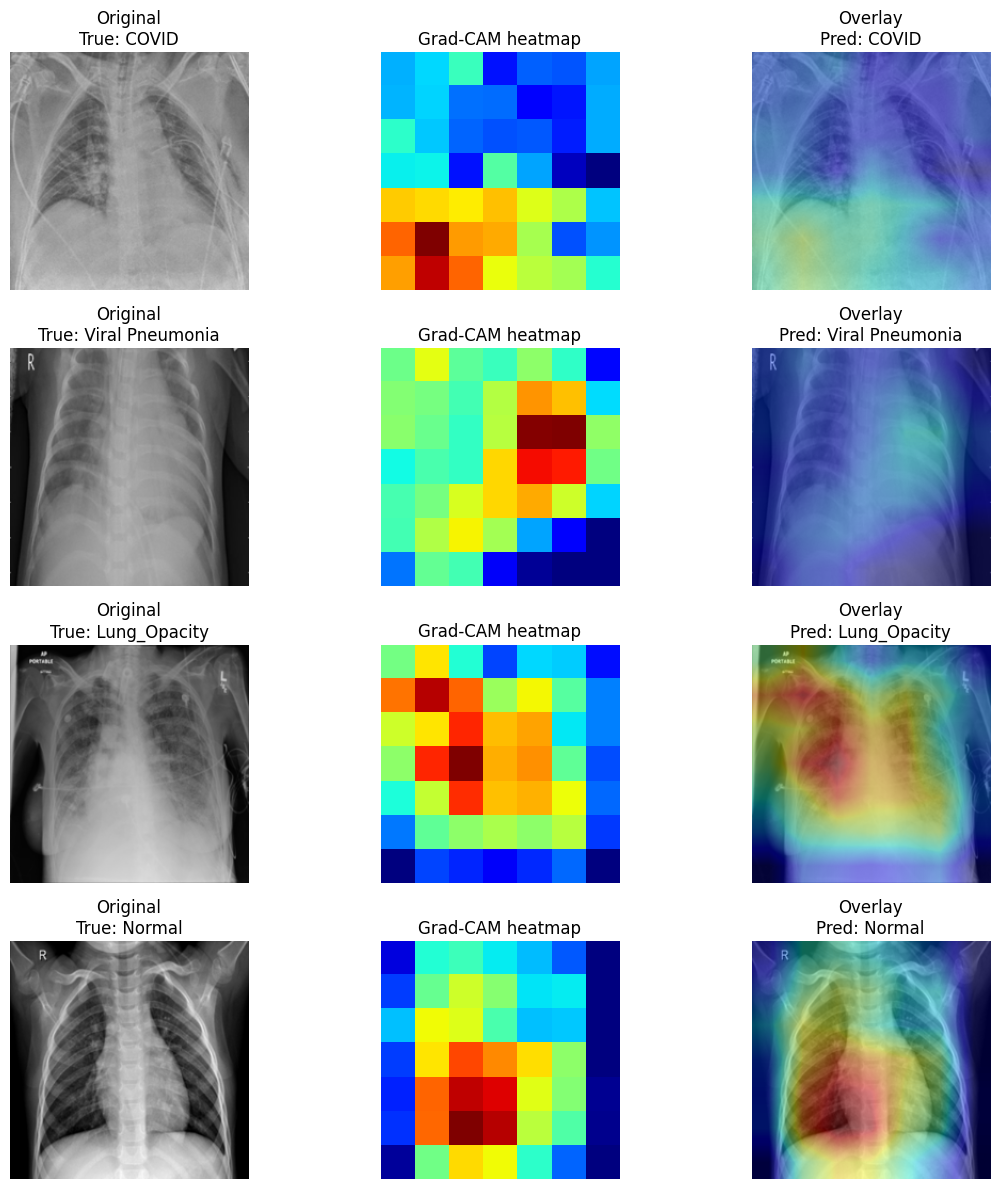

In [ ]:
n = len(correct_examples)
plt.figure(figsize=(12, 3 * n))

for i, (_, row) in enumerate(correct_examples.iterrows()):
    image_tensor = preprocess_single_image(row["path"])
    heatmap, probs = make_gradcam_heatmap(best_model, image_tensor, class_index=int(row["pred_id"]))
    overlay = overlay_heatmap(image_tensor, heatmap)

    plt.subplot(n, 3, 3*i + 1)
    plt.imshow(image_tensor.numpy())
    plt.title(f"Original\nTrue: {row['label']}")
    plt.axis("off")

    plt.subplot(n, 3, 3*i + 2)
    plt.imshow(heatmap, cmap="jet")
    plt.title("Grad-CAM heatmap")
    plt.axis("off")

    plt.subplot(n, 3, 3*i + 3)
    plt.imshow(overlay)
    plt.title(f"Overlay\nPred: {row['pred_label']}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 18. Grad-CAM for high-confidence errors

In [ ]:
mistakes = errors.head(4).reset_index(drop=True)

display(mistakes[["label", "pred_label", "confidence"]])

,label,pred_label,confidence
0,COVID,Normal,0.999888
1,Lung_Opacity,COVID,0.998964
2,Normal,Viral Pneumonia,0.998177
3,COVID,Normal,0.998099


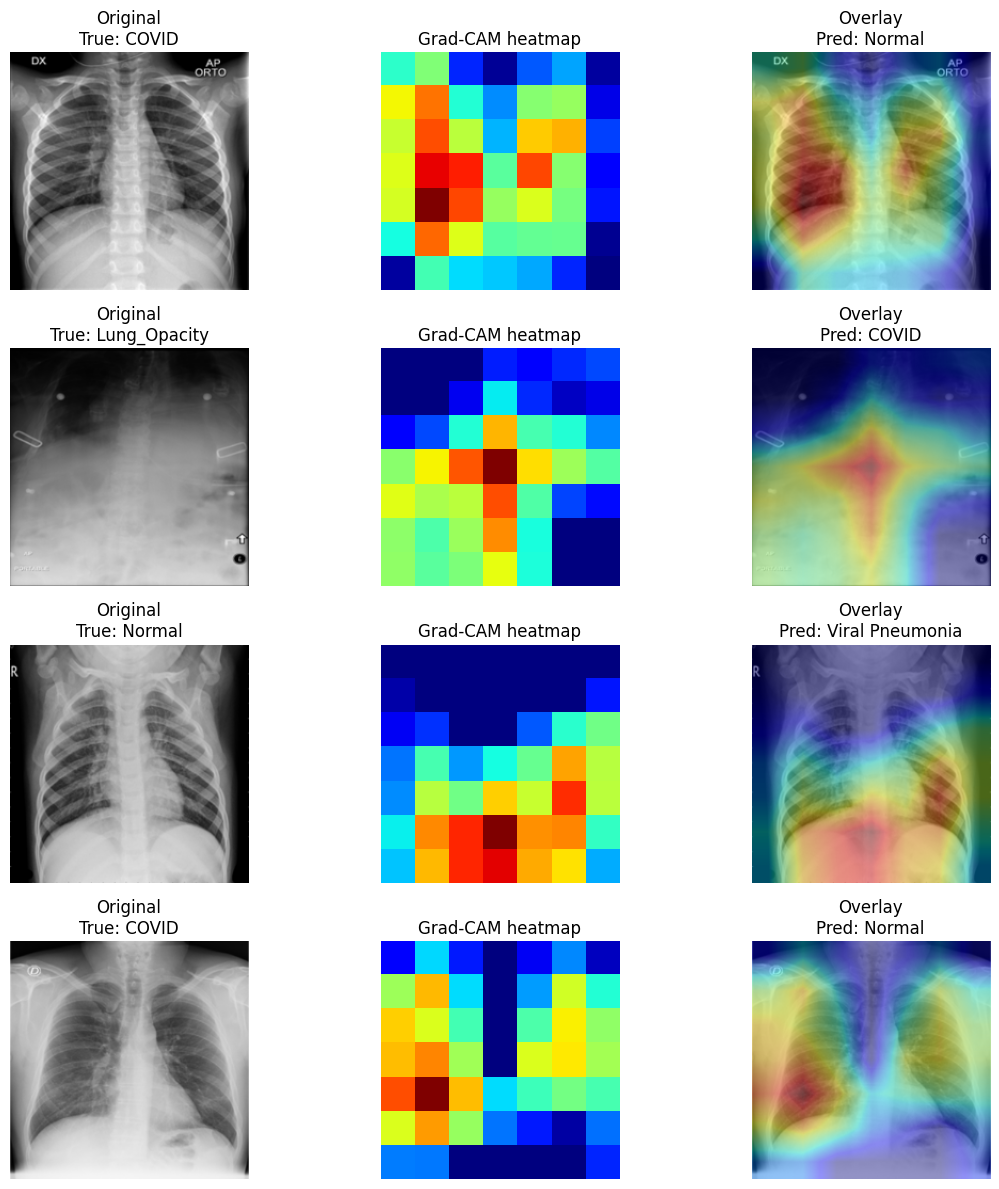

In [ ]:
if len(mistakes) > 0:
    n = len(mistakes)
    plt.figure(figsize=(12, 3 * n))

    for i, (_, row) in enumerate(mistakes.iterrows()):
        image_tensor = preprocess_single_image(row["path"])
        heatmap, probs = make_gradcam_heatmap(best_model, image_tensor, class_index=int(row["pred_id"]))
        overlay = overlay_heatmap(image_tensor, heatmap)

        plt.subplot(n, 3, 3*i + 1)
        plt.imshow(image_tensor.numpy())
        plt.title(f"Original\nTrue: {row['label']}")
        plt.axis("off")

        plt.subplot(n, 3, 3*i + 2)
        plt.imshow(heatmap, cmap="jet")
        plt.title("Grad-CAM heatmap")
        plt.axis("off")

        plt.subplot(n, 3, 3*i + 3)
        plt.imshow(overlay)
        plt.title(f"Overlay\nPred: {row['pred_label']}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("No misclassified examples found.")

## 19. Save outputs

In [ ]:
history_df.to_csv("mobilenetv2_twostage_training_history.csv", index=False)
mobilenet_metrics.to_csv("mobilenetv2_twostage_test_summary_metrics.csv", index=False)
sensitivity_specificity_df.to_csv("mobilenetv2_twostage_sensitivity_specificity.csv", index=False)
auroc_df.to_csv("mobilenetv2_twostage_auroc_by_class.csv", index=False)
auprc_df.to_csv("mobilenetv2_twostage_auprc_by_class.csv", index=False)
summary_auc.to_csv("mobilenetv2_twostage_auc_summary.csv", index=False)
test_results.to_csv("mobilenetv2_twostage_test_predictions.csv", index=False)

print("Saved:")
print("- split_train.csv")
print("- split_val.csv")
print("- split_test.csv")
print("- mobilenetv2_stage1_best_validation.keras")
print("- mobilenetv2_twostage_best_validation.keras")
print("- mobilenetv2_twostage_training_history.csv")
print("- mobilenetv2_twostage_test_summary_metrics.csv")
print("- mobilenetv2_twostage_sensitivity_specificity.csv")
print("- mobilenetv2_twostage_auroc_by_class.csv")
print("- mobilenetv2_twostage_auprc_by_class.csv")
print("- mobilenetv2_twostage_auc_summary.csv")
print("- mobilenetv2_twostage_test_predictions.csv")

Saved:
- split_train.csv
- split_val.csv
- split_test.csv
- mobilenetv2_stage1_best_validation.keras
- mobilenetv2_twostage_best_validation.keras
- mobilenetv2_twostage_training_history.csv
- mobilenetv2_twostage_test_summary_metrics.csv
- mobilenetv2_twostage_sensitivity_specificity.csv
- mobilenetv2_twostage_auroc_by_class.csv
- mobilenetv2_twostage_auprc_by_class.csv
- mobilenetv2_twostage_auc_summary.csv
- mobilenetv2_twostage_test_predictions.csv
